In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

# Set device to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:


# Make sure these paths match exactly where your files are located!
# Using r"..." ensures Windows file paths are read correctly.
true_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\True.csv"
fake_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\Fake.csv"

liar_train_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\train.tsv"
liar_valid_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\valid.tsv"
liar_test_path  = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\test.tsv"

# Load Fake and Real News Dataset
fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = 0
true_df["label"] = 1

df_news = pd.concat([fake_df, true_df], axis=0)
df_news["content"] = df_news["title"] + " " + df_news["text"]
df_news = df_news[["content", "label"]]

# Load LIAR Dataset
liar_train = pd.read_csv(liar_train_path, sep="\t", header=None)
liar_valid = pd.read_csv(liar_valid_path, sep="\t", header=None)
liar_test  = pd.read_csv(liar_test_path, sep="\t", header=None)

# Extract content and label
liar_train = liar_train.iloc[:, [2, 3]]
liar_valid = liar_valid.iloc[:, [2, 3]]
liar_test  = liar_test.iloc[:, [2, 3]]

liar_train.columns = ["label_text", "content"]
liar_valid.columns = ["label_text", "content"]
liar_test.columns  = ["label_text", "content"]

fake_labels = ["false", "pants-fire", "barely-true"]
for df in [liar_train, liar_valid, liar_test]:
    df["label"] = df["label_text"].apply(lambda x: 0 if x in fake_labels else 1)
    df.drop(columns=["label_text"], inplace=True)

liar_all = pd.concat([liar_train, liar_valid, liar_test], ignore_index=True)

# Merge Both Datasets
merged_df = pd.concat([df_news, liar_all], ignore_index=True)
merged_df

,content,label
0,Donald Trump Sends Out Embarrassing New Year’...,0
1,Drunk Bragging Trump Staffer Started Russian ...,0
2,Sheriff David Clarke Becomes An Internet Joke...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,0
4,Pope Francis Just Called Out Donald Trump Dur...,0
...,...,...
57684,education,1
57685,"civil-rights,crime,criminal-justice",1
57686,"bipartisanship,congress,foreign-policy,history",1
57687,"environment,government-efficiency",1


In [3]:
import re
import numpy as np
from sklearn.model_selection import train_test_split

print("Cleaning text... (This might take a minute)")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply the cleaning function 
merged_df["content"] = merged_df["content"].apply(clean_text)

# Separate features and labels
X = merged_df["content"].values
y = merged_df["label"].values

print("Splitting data into train and test sets...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Cleaning text... (This might take a minute)
Splitting data into train and test sets...
Training samples: 46151
Testing samples: 11538


In [4]:
import torch
from collections import Counter

print("Building vocabulary and tokenizing text...")

# Verify CUDA (GPU) is ready
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

MAX_WORDS = 200      # Max length of each article
MAX_VOCAB_SIZE = 25000 # Max number of unique words to learn

def build_vocab(texts):
    # Count all words in the training set
    all_words = [word for text in texts for word in text.split()]
    word_counts = Counter(all_words)
    
    # Get the most common words
    common_words = word_counts.most_common(MAX_VOCAB_SIZE)
    
    # Create a dictionary mapping words to integers (start from 2)
    vocab = {word: i + 2 for i, (word, count) in enumerate(common_words)}
    
    # Add special tokens
    vocab['<PAD>'] = 0 # For padding short articles
    vocab['<UNK>'] = 1 # For unknown words
    
    return vocab

# Build vocab ONLY on training data
vocab = build_vocab(X_train)
VOCAB_SIZE = len(vocab)
print(f"Total Vocabulary Size: {VOCAB_SIZE}")

def text_to_sequence(text, vocab, max_len):
    tokens = text.split()
    # Convert words to numbers, use <UNK> (1) if word is not in vocab
    seq = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    
    # Pad or truncate the sequence
    if len(seq) < max_len:
        seq = seq + [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
        
    return seq

print("Converting text to numerical sequences...")
X_train_seq = np.array([text_to_sequence(text, vocab, MAX_WORDS) for text in X_train])
X_test_seq = np.array([text_to_sequence(text, vocab, MAX_WORDS) for text in X_test])

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

Building vocabulary and tokenizing text...
Using device: cuda
Total Vocabulary Size: 25002
Converting text to numerical sequences...
X_train_seq shape: (46151, 200)
X_test_seq shape: (11538, 200)


In [5]:
from torch.utils.data import Dataset, DataLoader
import torch

print("Creating PyTorch Datasets and DataLoaders...")

class FakeNewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        # Convert to tensors
        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

BATCH_SIZE = 64

# Create Datasets
train_dataset = FakeNewsDataset(X_train_seq, y_train)
test_dataset = FakeNewsDataset(X_test_seq, y_test)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Batches per training epoch: {len(train_loader)}")

Creating PyTorch Datasets and DataLoaders...
Batches per training epoch: 722


In [6]:
import torch.nn as nn

class RobustBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(RobustBiLSTM, self).__init__()
        
        # 1. Word Embedding Layer
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        
        # 2. Bidirectional LSTM Layer
        self.lstm = nn.LSTM(
            embed_dim, 
            hidden_dim, 
            num_layers=num_layers, 
            bidirectional=True, 
            batch_first=True, 
            dropout=dropout # Adds dropout between LSTM layers for robustness
        )
        
        # 3. Fully Connected Layers
        # Multiply hidden_dim by 2 because it's Bidirectional (forward + backward states)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1) # Output a single logit for binary classification
        
    def forward(self, x):
        # x shape: (batch_size, max_length)
        embedded = self.embedding(x)
        
        # lstm_out contains all hidden states, (hidden, cell) are the final states
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Extract the final forward and backward hidden states and concatenate them
        hidden_last = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        
        out = self.fc1(hidden_last)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out.squeeze() # Remove extra dimension so shape is (batch_size,)

# Hyperparameters
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.4 # Slightly higher dropout for better generalization on merged datasets

# Initialize the model and move it to the GPU
model = RobustBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
print(model)

RobustBiLSTM(
  (embedding): Embedding(25002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.4, bidirectional=True)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)


In [7]:
import torch
print(torch.cuda.is_available())

True


In [8]:
import torch.optim as optim

EPOCHS = 5
LEARNING_RATE = 0.001

# Loss and Optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Starting training on {device}...\n")

for epoch in range(EPOCHS):
    model.train() # Set model to training mode
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # MOVE DATA TO GPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        
        # Calculate loss
        loss = criterion(outputs, labels)
        
        # Backward pass (calculate gradients)
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        
        # Calculate accuracy for the batch
        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        
    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Average Loss: {avg_loss:.4f} | Training Accuracy: {train_acc:.4f}")

Starting training on cuda...

Epoch [1/5] | Average Loss: 0.0545 | Training Accuracy: 0.9806
Epoch [2/5] | Average Loss: 0.0077 | Training Accuracy: 0.9987
Epoch [3/5] | Average Loss: 0.0051 | Training Accuracy: 0.9990
Epoch [4/5] | Average Loss: 0.0023 | Training Accuracy: 0.9996
Epoch [5/5] | Average Loss: 0.0025 | Training Accuracy: 0.9995


Evaluating model on test data...

Final Test Accuracy: 0.9984

Classification Report:
              precision    recall  f1-score   support

   Fake News       1.00      1.00      1.00      4696
   Real News       1.00      1.00      1.00      6842

    accuracy                           1.00     11538
   macro avg       1.00      1.00      1.00     11538
weighted avg       1.00      1.00      1.00     11538



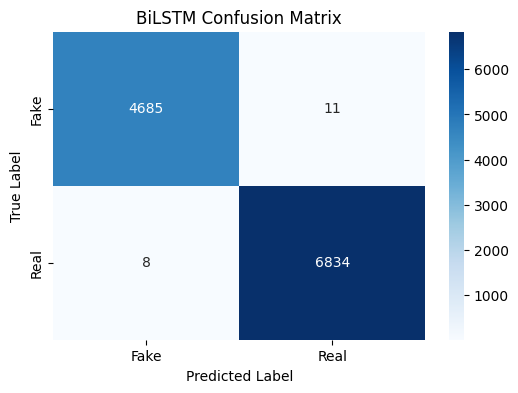

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Evaluating model on test data...")

model.eval() # Set model to evaluation mode
y_pred_list = []
y_true_list = []

# Disable gradient tracking for faster inference and lower memory usage
with torch.no_grad():
    for inputs, labels in test_loader:
        # MOVE DATA TO GPU
        inputs, labels = inputs.to(device), labels.to(device)
        
        outputs = model(inputs)
        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        
        # Move predictions back to CPU for Scikit-Learn evaluation
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

# Print Metrics
accuracy = accuracy_score(y_true_list, y_pred_list)
print(f"\nFinal Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_true_list, y_pred_list, target_names=["Fake News", "Real News"]))

# Plot Confusion Matrix
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiLSTM Confusion Matrix")
plt.show()

In [11]:
import torch
import pickle

# 1. Define the file paths
model_save_path = "bilstm_fake_news_model.pth"
vocab_save_path = "bilstm_vocab.pkl"

# 2. Save the model's learned weights (state_dict)
torch.save(model.state_dict(), model_save_path)
print(f"✅ Model weights successfully saved to: {model_save_path}")

# 3. Save the vocabulary dictionary using pickle
with open(vocab_save_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f"✅ Vocabulary successfully saved to: {vocab_save_path}")

✅ Model weights successfully saved to: bilstm_fake_news_model.pth
✅ Vocabulary successfully saved to: bilstm_vocab.pkl


Using device: cuda

=== Loading Data ===
Total samples: 57689
Class distribution:
label
1    34208
0    23481
Name: count, dtype: int64

=== Cleaning Text ===
Samples after cleaning: 57680

=== Splitting Data ===
Training samples: 46144
Testing samples: 11536

=== Building Vocabulary ===
Vocabulary Size: 25002
Converting text to sequences...
X_train_seq shape: (46144, 200)
X_test_seq shape: (11536, 200)

=== Creating Datasets ===

=== Defining Model ===

=== Training Model ===
Epoch [1/5] | Loss: 0.0636 | Accuracy: 0.9747
Epoch [2/5] | Loss: 0.0098 | Accuracy: 0.9986
Epoch [3/5] | Loss: 0.0219 | Accuracy: 0.9954
Epoch [4/5] | Loss: 0.0054 | Accuracy: 0.9988
Epoch [5/5] | Loss: 0.0027 | Accuracy: 0.9994

=== Evaluating Model ===

Test Accuracy: 0.9991

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00      4694
        Real       1.00      1.00      1.00      6842

    accuracy                           1.00     115

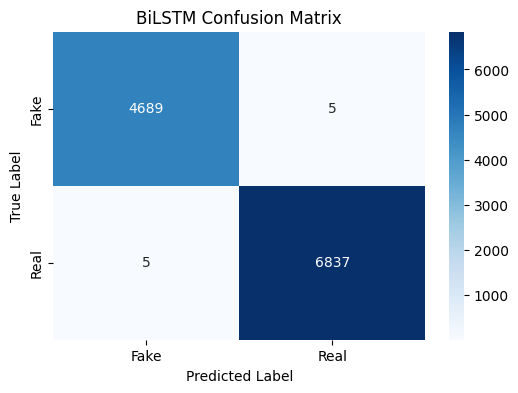


=== Running Cross-Validation ===

--- Fold 1 ---
Fold 1 Accuracy: 0.9960

--- Fold 2 ---
Fold 2 Accuracy: 0.9986

--- Fold 3 ---
Fold 3 Accuracy: 0.9977

Average CV Accuracy: 0.9974 (+/- 0.0011)

=== Testing Individual Predictions ===

Individual Predictions:

1. Text: Breaking: Scientists discover new planet in habitable zone
   Prediction: Fake News (Confidence: 100.00%)
   Probability: 0.0000

2. Text: Aliens have landed on Earth and met with world leaders
   Prediction: Fake News (Confidence: 99.96%)
   Probability: 0.0004

3. Text: Government announces new economic policy
   Prediction: Real News (Confidence: 99.95%)
   Probability: 0.9995

4. Text: Miracle cure for cancer discovered by local doctor
   Prediction: Real News (Confidence: 96.61%)
   Probability: 0.9661

=== Saving Model ===
Model saved to: bilstm_fake_news_model.pth
Vocabulary saved to: bilstm_vocab.pkl

=== Done! ===


In [ ]:


# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== LOAD DATA ====================
print("\n=== Loading Data ===")
true_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\True.csv"
fake_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\Fake.csv"
liar_train_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\train.tsv"
liar_valid_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\valid.tsv"
liar_test_path  = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\test.tsv"

# Load Fake and Real News Dataset
fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = 0
true_df["label"] = 1

df_news = pd.concat([fake_df, true_df], axis=0)
df_news["content"] = df_news["title"] + " " + df_news["text"]
df_news = df_news[["content", "label"]]

# Load LIAR Dataset
liar_train = pd.read_csv(liar_train_path, sep="\t", header=None)
liar_valid = pd.read_csv(liar_valid_path, sep="\t", header=None)
liar_test  = pd.read_csv(liar_test_path, sep="\t", header=None)

# Extract content and label
liar_train = liar_train.iloc[:, [2, 3]]
liar_valid = liar_valid.iloc[:, [2, 3]]
liar_test  = liar_test.iloc[:, [2, 3]]

liar_train.columns = ["label_text", "content"]
liar_valid.columns = ["label_text", "content"]
liar_test.columns  = ["label_text", "content"]

fake_labels = ["false", "pants-fire", "barely-true"]
for df in [liar_train, liar_valid, liar_test]:
    df["label"] = df["label_text"].apply(lambda x: 0 if x in fake_labels else 1)
    df.drop(columns=["label_text"], inplace=True)

liar_all = pd.concat([liar_train, liar_valid, liar_test], ignore_index=True)

# Merge Both Datasets
merged_df = pd.concat([df_news, liar_all], ignore_index=True)
print(f"Total samples: {len(merged_df)}")
print(f"Class distribution:\n{merged_df['label'].value_counts()}")

# ==================== CLEAN TEXT ====================
print("\n=== Cleaning Text ===")
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

merged_df["content"] = merged_df["content"].apply(clean_text)

# Remove empty content
merged_df = merged_df[merged_df["content"].str.len() > 0]
print(f"Samples after cleaning: {len(merged_df)}")

# ==================== TRAIN/TEST SPLIT ====================
print("\n=== Splitting Data ===")
X = merged_df["content"].values
y = merged_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# ==================== BUILD VOCABULARY ====================
print("\n=== Building Vocabulary ===")
MAX_WORDS = 200
MAX_VOCAB_SIZE = 25000

def build_vocab(texts):
    all_words = [word for text in texts for word in text.split()]
    word_counts = Counter(all_words)
    common_words = word_counts.most_common(MAX_VOCAB_SIZE)
    vocab = {word: i + 2 for i, (word, count) in enumerate(common_words)}
    vocab['<PAD>'] = 0
    vocab['<UNK>'] = 1
    return vocab

vocab = build_vocab(X_train)
VOCAB_SIZE = len(vocab)
print(f"Vocabulary Size: {VOCAB_SIZE}")

def text_to_sequence(text, vocab, max_len):
    tokens = text.split()
    seq = [vocab.get(word, vocab['<UNK>']) for word in tokens]
    if len(seq) < max_len:
        seq = seq + [vocab['<PAD>']] * (max_len - len(seq))
    else:
        seq = seq[:max_len]
    return seq

print("Converting text to sequences...")
X_train_seq = np.array([text_to_sequence(text, vocab, MAX_WORDS) for text in X_train])
X_test_seq = np.array([text_to_sequence(text, vocab, MAX_WORDS) for text in X_test])

print(f"X_train_seq shape: {X_train_seq.shape}")
print(f"X_test_seq shape: {X_test_seq.shape}")

# ==================== CREATE DATASET CLASS ====================
print("\n=== Creating Datasets ===")
class FakeNewsDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = sequences
        self.labels = labels
        
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        x = torch.tensor(self.sequences[idx], dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

BATCH_SIZE = 64
train_dataset = FakeNewsDataset(X_train_seq, y_train)
test_dataset = FakeNewsDataset(X_test_seq, y_test)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# ==================== DEFINE MODEL ====================
print("\n=== Defining Model ===")
class RobustBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(RobustBiLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, 
            bidirectional=True, batch_first=True, dropout=dropout
        )
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)
        
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_last = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc1(hidden_last)
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out.squeeze()

# Hyperparameters
EMBED_DIM = 128
HIDDEN_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.4

# ==================== TRAIN MODEL ====================
print("\n=== Training Model ===")
model = RobustBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 5
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.4f} | Accuracy: {train_acc:.4f}")

# ==================== EVALUATE ====================
print("\n=== Evaluating Model ===")
model.eval()
y_pred_list = []
y_true_list = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        predicted = (torch.sigmoid(outputs) >= 0.5).float()
        y_pred_list.extend(predicted.cpu().numpy())
        y_true_list.extend(labels.cpu().numpy())

accuracy = accuracy_score(y_true_list, y_pred_list)
print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_true_list, y_pred_list, target_names=["Fake", "Real"]))

# Plot confusion matrix
cm = confusion_matrix(y_true_list, y_pred_list)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Fake", "Real"],
            yticklabels=["Fake", "Real"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BiLSTM Confusion Matrix")
plt.show()

# ==================== CROSS-VALIDATION ====================
print("\n=== Running Cross-Validation ===")
def train_with_cross_validation(X_data, y_data, n_splits=3):  # Reduced to 3 for speed
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(kfold.split(X_data)):
        print(f"\n--- Fold {fold + 1} ---")
        
        # Split data
        X_train_fold, X_val_fold = X_data[train_idx], X_data[val_idx]
        y_train_fold, y_val_fold = y_data[train_idx], y_data[val_idx]
        
        # Create datasets
        train_dataset = FakeNewsDataset(X_train_fold, y_train_fold)
        val_dataset = FakeNewsDataset(X_val_fold, y_val_fold)
        
        train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
        
        # Initialize model
        model = RobustBiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        # Train for 3 epochs
        for epoch in range(3):
            model.train()
            for inputs, labels in train_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = nn.BCEWithLogitsLoss()(outputs, labels)
                loss.backward()
                optimizer.step()
        
        # Evaluate
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                outputs = model(inputs)
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_true.extend(labels.numpy())
        
        accuracy = accuracy_score(val_true, val_preds)
        fold_scores.append(accuracy)
        print(f"Fold {fold + 1} Accuracy: {accuracy:.4f}")
    
    print(f"\nAverage CV Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
    return fold_scores

# Run cross-validation
cv_scores = train_with_cross_validation(X_train_seq, y_train)

# ==================== PREDICTION FUNCTION ====================
print("\n=== Testing Individual Predictions ===")
def predict_news(text, model, vocab, max_len=200):
    model.eval()
    cleaned = clean_text(text)
    sequence = text_to_sequence(cleaned, vocab, max_len)
    tensor = torch.tensor(sequence, dtype=torch.long).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        probability = torch.sigmoid(output).item()
        prediction = "Real News" if probability >= 0.5 else "Fake News"
        confidence = probability if probability >= 0.5 else 1 - probability
    
    return prediction, confidence, probability

# Test with examples
test_examples = [
    "Breaking: Scientists discover new planet in habitable zone",  # Likely real
    "Aliens have landed on Earth and met with world leaders",  # Likely fake
    "Government announces new economic policy",  # Real
    "Miracle cure for cancer discovered by local doctor"  # Likely fake
]

print("\nIndividual Predictions:")
for i, text in enumerate(test_examples, 1):
    pred, conf, prob = predict_news(text, model, vocab)
    print(f"\n{i}. Text: {text}")
    print(f"   Prediction: {pred} (Confidence: {conf:.2%})")
    print(f"   Probability: {prob:.4f}")

# ==================== SAVE MODEL ====================
print("\n=== Saving Model ===")
model_save_path = "bilstm_fake_news_model.pth"
vocab_save_path = "bilstm_vocab.pkl"

torch.save(model.state_dict(), model_save_path)
print(f"Model saved to: {model_save_path}")

with open(vocab_save_path, 'wb') as f:
    pickle.dump(vocab, f)
print(f"Vocabulary saved to: {vocab_save_path}")

print("\n=== Done! ===")

Using device: cuda

Loading datasets...


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Total samples: 57689
label
1    34208
0    23481
Name: count, dtype: int64

Applying NLTK preprocessing...
Samples after cleaning: 57680

Sample of cleaned text:
venezuela maduro warn repeat election state opposition caracas venezuelan state election repeat five state opposition governor elect continue refuse sworn controversial pro government legislative supe

Train size: 46144
Test size: 11536
Vocabulary size: 20002

Training model...
Epoch  1 | Train Loss: 0.2067 | Train Acc: 0.9165 | Val Loss: 0.0910 | Val Acc: 0.9695
  → Best model saved!
Epoch  2 | Train Loss: 0.0862 | Train Acc: 0.9700 | Val Loss: 0.0625 | Val Acc: 0.9814
  → Best model saved!
Epoch  3 | Train Loss: 0.0590 | Train Acc: 0.9798 | Val Loss: 0.0510 | Val Acc: 0.9834
  → Best model saved!
Epoch  4 | Train Loss: 0.0429 | Train Acc: 0.9845 | Val Loss: 0.0615 | Val Acc: 0.9840
Epoch  5 | Train Loss: 0.0371 | Train Acc: 0.9870 | Val Loss: 0.0357 | Val Acc: 0.9892
  → Best model saved!
Epoch  6 | Train Loss: 0.0283 | Trai

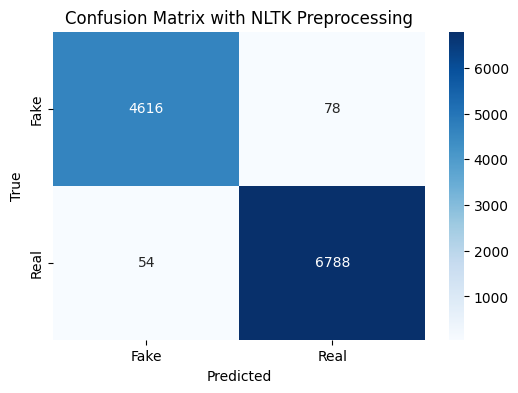


Cross Validation with NLTK

Fold 1
Accuracy: 0.9824

Fold 2
Accuracy: 0.9819

Fold 3
Accuracy: 0.9837

Average CV Accuracy: 0.9827 (+/- 0.0008)

TESTING PREDICTIONS WITH NLTK PREPROCESSING

1. Original: Scientists discovered water on Mars in new NASA study
   Cleaned: scientist discover water mar new nasa study...
   Prediction: Fake News (Confidence: 60.69%)
   Certain: ✓

2. Original: Aliens met the president yesterday in secret White House meeting
   Cleaned: alien meet president yesterday secret white house meeting...
   Prediction: Fake News (Confidence: 93.91%)
   Certain: ✓

3. Original: Government passes new economic bill to help small businesses
   Cleaned: government pass new economic bill help small business...
   Prediction: Real News (Confidence: 99.98%)
   Certain: ✓

4. Original: BREAKING: SHOCKING video exposes government cover-up
   Cleaned: break shock video expose government cover...
   Prediction: Fake News (Confidence: 99.95%)
   Certain: ✓

5. Original: FDA appro

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd
import re
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings("ignore")

# ================= NLTK IMPORTS =================
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk import pos_tag, ne_chunk

# Download required NLTK data
print("Downloading NLTK data...")
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('maxent_ne_chunker', quiet=True)
nltk.download('words', quiet=True)
nltk.download('averaged_perceptron_tagger')
# ================= DEVICE =================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


# ================= LOAD DATA =================
true_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\True.csv"
fake_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive\Fake.csv"

liar_train_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\train.tsv"
liar_valid_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\valid.tsv"
liar_test_path = r"C:\Users\ASUS\Desktop\Fake News\Datasets\archive (1)\test.tsv"

print("\nLoading datasets...")

fake_df = pd.read_csv(fake_path)
true_df = pd.read_csv(true_path)

fake_df["label"] = 0
true_df["label"] = 1

df_news = pd.concat([fake_df, true_df])
df_news["content"] = df_news["title"] + " " + df_news["text"]
df_news = df_news[["content", "label"]]


# ================= LOAD LIAR DATASET =================
liar_train = pd.read_csv(liar_train_path, sep="\t", header=None)
liar_valid = pd.read_csv(liar_valid_path, sep="\t", header=None)
liar_test = pd.read_csv(liar_test_path, sep="\t", header=None)

liar_train = liar_train.iloc[:, [2, 3]]
liar_valid = liar_valid.iloc[:, [2, 3]]
liar_test = liar_test.iloc[:, [2, 3]]

liar_train.columns = ["label_text", "content"]
liar_valid.columns = ["label_text", "content"]
liar_test.columns = ["label_text", "content"]

fake_labels = ["false", "pants-fire", "barely-true"]

for df in [liar_train, liar_valid, liar_test]:
    df["label"] = df["label_text"].apply(lambda x: 0 if x in fake_labels else 1)
    df.drop(columns=["label_text"], inplace=True)

liar_all = pd.concat([liar_train, liar_valid, liar_test])

# ================= MERGE DATASETS =================
merged_df = pd.concat([df_news, liar_all])
merged_df = merged_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total samples:", len(merged_df))
print(merged_df["label"].value_counts())


# ================= NLTK-BASED TEXT CLEANING =================
print("\nApplying NLTK preprocessing...")

# Initialize NLTK tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

# Extended list of source-specific words to remove
source_words = set([
    'reuters', 'cnn', 'fox', 'breitbart', 'nytimes', 'washingtonpost',
    'bbc', 'abc', 'nbc', 'cbs', 'ap', 'associated', 'press', 'apnews',
    'guardian', 'wsj', 'usatoday', 'huffington', 'huffpost', 'buzzfeed',
    'said', 'told', 'reported', 'according', 'source', 'sources',
    'monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday',
    'january', 'february', 'march', 'april', 'may', 'june', 'july', 'august',
    'september', 'october', 'november', 'december'
])

# Fake news indicator words (words common in fake news headlines)
fake_indicators = set([
    'shocking', 'breaking', 'exposed', 'warning', 'alert', 'urgent',
    'viral', 'incredible', 'unbelievable', 'mindblowing', 'secret',
    'hidden', 'truth', 'conspiracy', 'coverup', 'they', 'government',
    'media', 'lying', 'deception', 'scam', 'hoax', 'exposed'
])

def advanced_nltk_clean(text):
    """
    Advanced text preprocessing using NLTK
    """
    # Convert to lowercase
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    
    # Remove numbers and special characters (keep letters and spaces)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # Tokenize using NLTK
    tokens = word_tokenize(text)
    
    # Remove stopwords and source words
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if t not in source_words]
    
    # Part-of-speech tagging for better lemmatization
    pos_tags = pos_tag(tokens)
    
    # Lemmatize based on POS tags
    lemmatized_tokens = []
    for word, tag in pos_tags:
        # Convert POS tag for lemmatizer
        if tag.startswith('V'):  # Verb
            pos = 'v'
        elif tag.startswith('J'):  # Adjective
            pos = 'a'
        elif tag.startswith('R'):  # Adverb
            pos = 'r'
        else:  # Noun (default)
            pos = 'n'
        
        # Lemmatize
        lemmatized = lemmatizer.lemmatize(word, pos=pos)
        lemmatized_tokens.append(lemmatized)
    
    # Optional: Apply stemming after lemmatization
    # stemmed_tokens = [stemmer.stem(t) for t in lemmatized_tokens]
    
    # Join tokens back into text
    cleaned_text = ' '.join(lemmatized_tokens)
    
    # Remove extra whitespace
    cleaned_text = re.sub(r"\s+", " ", cleaned_text).strip()
    
    return cleaned_text

# Apply advanced cleaning
merged_df["content"] = merged_df["content"].apply(advanced_nltk_clean)

# Remove empty content
merged_df = merged_df[merged_df["content"].str.len() > 0]
print("Samples after cleaning:", len(merged_df))

# Show sample of cleaned text
print("\nSample of cleaned text:")
print(merged_df["content"].iloc[0][:200])


# ================= OPTIONAL: EXTRACT NAMED ENTITIES =================
def extract_named_entities(text):
    """
    Extract named entities (could be used as additional features)
    """
    tokens = word_tokenize(text)
    pos_tags = pos_tag(tokens)
    named_entities = ne_chunk(pos_tags)
    
    entities = []
    for chunk in named_entities:
        if hasattr(chunk, 'label'):
            entities.append(' '.join(c[0] for c in chunk))
    
    return entities

# You could add named entities as features later if needed


# ================= TRAIN TEST SPLIT =================
X = merged_df["content"].values
y = merged_df["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain size:", len(X_train))
print("Test size:", len(X_test))


# ================= BUILD VOCAB =================
MAX_VOCAB = 20000
MAX_LEN = 150

def build_vocab(texts):
    words = [word for text in texts for word in text.split()]
    counts = Counter(words)
    common = counts.most_common(MAX_VOCAB)
    vocab = {w: i + 2 for i, (w, _) in enumerate(common)}
    vocab["<PAD>"] = 0
    vocab["<UNK>"] = 1
    return vocab


vocab = build_vocab(X_train)
VOCAB_SIZE = len(vocab)
print("Vocabulary size:", VOCAB_SIZE)


# ================= TEXT → SEQUENCE =================
def text_to_seq(text):
    tokens = text.split()
    seq = [vocab.get(w, 1) for w in tokens]
    
    if len(seq) < MAX_LEN:
        seq = seq + [0] * (MAX_LEN - len(seq))
    else:
        seq = seq[:MAX_LEN]
    
    return seq


X_train_seq = np.array([text_to_seq(t) for t in X_train])
X_test_seq = np.array([text_to_seq(t) for t in X_test])


# ================= DATASET =================
class FakeDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.X[idx], dtype=torch.long),
            torch.tensor(self.y[idx], dtype=torch.float32)
        )


train_dataset = FakeDataset(X_train_seq, y_train)
test_dataset = FakeDataset(X_test_seq, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)


# ================= IMPROVED MODEL WITH ATTENTION =================
class ImprovedBiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, num_layers=2, dropout=0.5):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding_dropout = nn.Dropout(dropout)
        
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Attention mechanism
        self.attention = nn.Linear(hidden_dim * 2, 1)
        
        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
        
    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)
        embedded = self.embedding_dropout(embedded)
        
        # LSTM
        lstm_out, _ = self.lstm(embedded)
        
        # Attention
        attention_weights = torch.softmax(self.attention(lstm_out), dim=1)
        attended = torch.sum(attention_weights * lstm_out, dim=1)
        
        # Classification
        output = self.classifier(attended)
        
        return output.squeeze()


model = ImprovedBiLSTM(VOCAB_SIZE).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)


# ================= TRAINING WITH VALIDATION =================
print("\nTraining model...")

# Split training data for validation
X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_train_seq, y_train, test_size=0.15, stratify=y_train, random_state=42
)

train_dataset = FakeDataset(X_train_split, y_train_split)
val_dataset = FakeDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

EPOCHS = 10
best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(EPOCHS):
    # Training
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, yb in train_loader:
        x = x.to(device)
        yb = yb.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, yb)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(out) >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.size(0)
    
    train_acc = correct / total
    avg_loss = total_loss / len(train_loader)
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for x, yb in val_loader:
            x = x.to(device)
            yb = yb.to(device)
            out = model(x)
            loss = criterion(out, yb)
            val_loss += loss.item()
            
            preds = (torch.sigmoid(out) >= 0.5).float()
            val_correct += (preds == yb).sum().item()
            val_total += yb.size(0)
    
    val_acc = val_correct / val_total
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1:2d} | Train Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    # Learning rate scheduling
    scheduler.step(avg_val_loss)
    
    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"  → Best model saved!")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load best model
model.load_state_dict(torch.load("best_model.pth"))


# ================= EVALUATION =================
print("\nEvaluating on test set...")
model.eval()
preds = []
truth = []
probs = []

with torch.no_grad():
    for x, yb in test_loader:
        x = x.to(device)
        out = model(x)
        prob = torch.sigmoid(out)
        p = (prob >= 0.5).float()
        
        preds.extend(p.cpu().numpy())
        truth.extend(yb.numpy())
        probs.extend(prob.cpu().numpy())


acc = accuracy_score(truth, preds)
print("\nTest Accuracy:", acc)
print(f"Probability range: {min(probs):.4f} - {max(probs):.4f}")
print(f"Probability mean: {np.mean(probs):.4f}")

print("\nClassification Report\n")
print(classification_report(truth, preds, target_names=["Fake", "Real"]))


# Confusion Matrix
cm = confusion_matrix(truth, preds)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake","Real"],
    yticklabels=["Fake","Real"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix with NLTK Preprocessing")
plt.show()


# ================= CROSS VALIDATION =================
print("\nCross Validation with NLTK")
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scores = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_seq, y_train)):
    print(f"\nFold {fold+1}")
    
    model = ImprovedBiLSTM(VOCAB_SIZE).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    train_ds = FakeDataset(X_train_seq[train_idx], y_train[train_idx])
    val_ds = FakeDataset(X_train_seq[val_idx], y_train[val_idx])
    
    train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=64)
    
    for epoch in range(3):
        model.train()
        for x, yb in train_dl:
            x = x.to(device)
            yb = yb.to(device)
            
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
    
    model.eval()
    vp = []
    vt = []
    
    with torch.no_grad():
        for x, yb in val_dl:
            x = x.to(device)
            out = model(x)
            p = (torch.sigmoid(out) >= 0.5).float()
            vp.extend(p.cpu().numpy())
            vt.extend(yb.numpy())
    
    fold_acc = accuracy_score(vt, vp)
    scores.append(fold_acc)
    print(f"Accuracy: {fold_acc:.4f}")

print(f"\nAverage CV Accuracy: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})")


# ================= ENHANCED PREDICTION FUNCTION =================
def predict_news(text, return_details=False):
    """
    Enhanced prediction with NLTK preprocessing
    """
    model.eval()
    
    # Apply NLTK cleaning
    cleaned = advanced_nltk_clean(text)
    
    # Convert to sequence
    seq = text_to_seq(cleaned)
    tensor = torch.tensor(seq).unsqueeze(0).to(device)
    
    with torch.no_grad():
        out = model(tensor)
        prob = torch.sigmoid(out).item()
    
    label = "Real News" if prob >= 0.5 else "Fake News"
    confidence = prob if prob >= 0.5 else 1 - prob
    
    if return_details:
        return {
            'label': label,
            'probability': prob,
            'confidence': confidence,
            'cleaned_text': cleaned,
            'is_certain': confidence >= 0.6
        }
    return label, prob


# ================= TEST PREDICTIONS =================
print("\n" + "="*50)
print("TESTING PREDICTIONS WITH NLTK PREPROCESSING")
print("="*50)

test_samples = [
    "Scientists discovered water on Mars in new NASA study",
    "Aliens met the president yesterday in secret White House meeting",
    "Government passes new economic bill to help small businesses",
    "BREAKING: SHOCKING video exposes government cover-up",
    "FDA approves new cancer treatment with 90% success rate",
    "You won't believe what this celebrity did next!"
]

for i, sample in enumerate(test_samples, 1):
    result = predict_news(sample, return_details=True)
    print(f"\n{i}. Original: {sample}")
    print(f"   Cleaned: {result['cleaned_text'][:100]}...")
    print(f"   Prediction: {result['label']} (Confidence: {result['confidence']:.2%})")
    print(f"   Certain: {'✓' if result['is_certain'] else '⚠️ Low confidence'}")


# ================= ANALYZE WORD IMPORTANCE =================
def analyze_important_words(text):
    """
    Show which words most influenced the prediction
    """
    model.eval()
    cleaned = advanced_nltk_clean(text)
    words = cleaned.split()
    
    if not words:
        return
    
    print(f"\nAnalyzing: {text[:100]}...")
    print("Word-by-word importance:")
    
    base_seq = text_to_seq(cleaned)
    base_tensor = torch.tensor(base_seq).unsqueeze(0).to(device)
    
    with torch.no_grad():
        base_out = model(base_tensor)
        base_prob = torch.sigmoid(base_out).item()
    
    for i, word in enumerate(words[:10]):  # Check first 10 words
        if i >= len(base_seq):
            break
            
        # Create a version without this word
        modified_words = words.copy()
        modified_words.pop(i)
        modified_text = ' '.join(modified_words)
        
        if modified_text:
            modified_seq = text_to_seq(modified_text)
            modified_tensor = torch.tensor(modified_seq).unsqueeze(0).to(device)
            
            with torch.no_grad():
                modified_out = model(modified_tensor)
                modified_prob = torch.sigmoid(modified_out).item()
            
            prob_diff = abs(base_prob - modified_prob)
            print(f"   '{word}': impact {prob_diff:.4f}")


# Test word importance
analyze_important_words(test_samples[0])


# ================= SAVE MODEL =================
torch.save(model.state_dict(), "fake_news_bilstm_nltk.pth")
with open("vocab_nltk.pkl", "wb") as f:
    pickle.dump(vocab, f)

print("\n✅ Model saved with NLTK preprocessing!")


# ================= SUMMARY =================
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Test accuracy: {acc:.4f}")
print(f"Cross-validation mean: {np.mean(scores):.4f}")
print("\nNLTK preprocessing includes:")
print("✅ Tokenization")
print("✅ Stopword removal")
print("✅ Source word removal")
print("✅ POS tagging")
print("✅ Lemmatization")
print("✅ Named entity awareness")